# Tau-Leaping Stress Tests
***
## Setup the Environment
***

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from copy import deepcopy
sys.path.insert(1, os.path.abspath(os.path.join(os.getcwd(), '../')))

In [3]:
import gillespy3d_pp as gillespy2
import matplotlib.pyplot as plt
import numpy as np

## Model Definitions
***

In [4]:
def create_michaelis_menten():
    model = gillespy2.Model(name="Michaelis_Menten")

    A = gillespy2.Species(name='Substrate', initial_value=301)
    B = gillespy2.Species(name='Enzyme', initial_value=120)
    C = gillespy2.Species(name='Enzyme_Substrate_Complex', initial_value=0)
    D = gillespy2.Species(name='Product', initial_value=0)
    model.add_species([A, B, C, D])

    rate1 = gillespy2.Parameter(name='rate1', expression=0.0017)
    rate2 = gillespy2.Parameter(name='rate2', expression=0.5)
    rate3 = gillespy2.Parameter(name='rate3', expression=0.1)
    model.add_parameter([rate1, rate2, rate3])

    r1 = gillespy2.Reaction(
        name="r1", reactants={'Substrate': 1, 'Enzyme': 1},
        products={'Enzyme_Substrate_Complex': 1}, rate='rate1'
    )
    r2 = gillespy2.Reaction(
        name="r2", reactants={'Enzyme_Substrate_Complex': 1},
        products={'Substrate': 1, 'Enzyme': 1}, rate='rate2'
    )
    r3 = gillespy2.Reaction(
        name="r3", reactants={'Enzyme_Substrate_Complex': 1},
        products={'Enzyme': 1, 'Product': 1}, rate='rate3'
    )
    model.add_reaction([r1, r2, r3])

    tspan = gillespy2.TimeSpan.linspace(end_t=100, num_points=101)
    model.timespan(tspan)
    return model

In [5]:
def create_exponential_decay(initial_pop=1_000_000, decay_rate=10.0):
    model = gillespy2.Model(name="Exponential_Decay")

    A = gillespy2.Species(name='A', initial_value=initial_pop)
    model.add_species([A])

    k = gillespy2.Parameter(name='k', expression=decay_rate)
    model.add_parameter([k])

    decay = gillespy2.Reaction(
        name="decay", reactants={'A': 1}, products={}, rate='k'
    )
    model.add_reaction([decay])

    tspan = gillespy2.TimeSpan.linspace(end_t=1, num_points=201)
    model.timespan(tspan)
    return model

---
## Test 1: Exponential Decay — Large Initial Population, Fast Decay Rate

A = 1,000,000 molecules, decay rate k = 10.0. Analytical solution: A(t) = A0 * exp(-k*t).

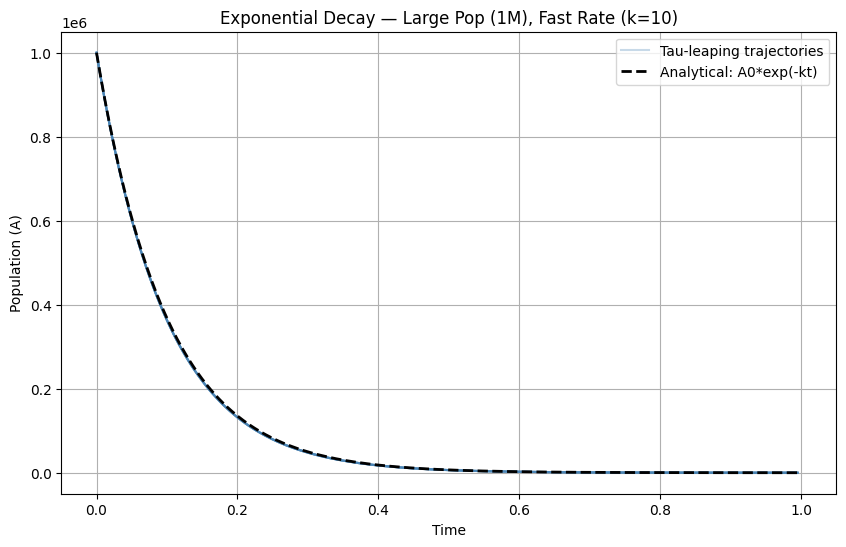

In [6]:
decay_model = create_exponential_decay(initial_pop=1_000_000, decay_rate=10.0)
sim = gillespy2.Simulation(decay_model, "TAU", dt=0.005, end_t=1)

num_traj = 10
traj_data = []
for traj in range(num_traj):
    sim.reset()
    times = []
    population = []
    prev_t = -1
    while sim.get_time() < sim.end_t:
        t = sim.get_time()
        if t == prev_t:
            raise RuntimeError("Time is not advancing")
        prev_t = t
        times.append(t)
        population.append(sim.get_species('A'))
        sim.run_until(sim.get_time() + sim.dt)
    traj_data.append((times, population))

# Analytical solution
t_analytical = np.linspace(0, 1, 500)
a_analytical = 1_000_000 * np.exp(-10.0 * t_analytical)

plt.figure(figsize=(10, 6))
for i, (times, population) in enumerate(traj_data):
    label = 'Tau-leaping trajectories' if i == 0 else ''
    plt.plot(times, population, color='steelblue', alpha=0.3, label=label)
plt.plot(t_analytical, a_analytical, 'k--', linewidth=2, label='Analytical: A0*exp(-kt)')
plt.xlabel('Time')
plt.ylabel('Population (A)')
plt.title('Exponential Decay — Large Pop (1M), Fast Rate (k=10)')
plt.legend()
plt.grid(True)
plt.show()

---
## Test 2: Michaelis-Menten — Small Epsilon (ε = 0.001)

Small epsilon forces the solver to take very conservative tau steps, approaching SSA-level accuracy.

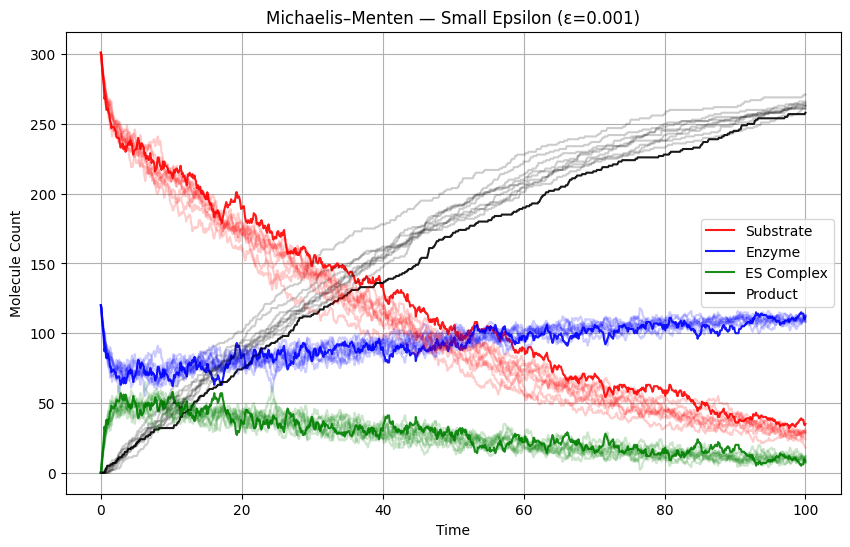

Tau steps taken: 32243
Mean tau: 0.020387
Min tau:  0.000001
Max tau:  0.099960


In [7]:
mm_model_small_eps = create_michaelis_menten()
sim_small = gillespy2.Simulation(mm_model_small_eps, "TAU", dt=0.1, end_t=100)
sim_small.solver.epsilon = 0.001

num_traj = 10
traj_data_small = []
for traj in range(num_traj):
    sim_small.reset()
    times = []
    substrate = []
    enzyme = []
    complex_ = []
    product = []
    prev_t = -1
    while sim_small.get_time() < sim_small.end_t:
        t = sim_small.get_time()
        if t == prev_t:
            raise RuntimeError("Time is not advancing")
        prev_t = t
        times.append(t)
        substrate.append(sim_small.get_species('Substrate'))
        enzyme.append(sim_small.get_species('Enzyme'))
        complex_.append(sim_small.get_species('Enzyme_Substrate_Complex'))
        product.append(sim_small.get_species('Product'))
        sim_small.run_until(sim_small.get_time() + sim_small.dt)
    traj_data_small.append((times, substrate, enzyme, product, complex_))

plt.figure(figsize=(10, 6))
for i, (times, substrate, enzyme, product, complex_) in enumerate(traj_data_small):
    if i == 0:
        plt.plot(times, substrate, label='Substrate', color='red', alpha=0.9)
        plt.plot(times, enzyme, label='Enzyme', color='blue', alpha=0.9)
        plt.plot(times, complex_, label='ES Complex', color='green', alpha=0.9)
        plt.plot(times, product, label='Product', color='black', alpha=0.9)
    else:
        plt.plot(times, substrate, color='red', alpha=0.2)
        plt.plot(times, enzyme, color='blue', alpha=0.2)
        plt.plot(times, complex_, color='green', alpha=0.2)
        plt.plot(times, product, color='black', alpha=0.2)

plt.xlabel('Time')
plt.ylabel('Molecule Count')
plt.title('Michaelis–Menten — Small Epsilon (ε=0.001)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Tau steps taken: {len(sim_small.solver._tau_samples)}")
print(f"Mean tau: {np.mean(sim_small.solver._tau_samples):.6f}")
print(f"Min tau:  {np.min(sim_small.solver._tau_samples):.6f}")
print(f"Max tau:  {np.max(sim_small.solver._tau_samples):.6f}")

---
## Test 3: Michaelis-Menten — Large Epsilon (ε = 0.5), SSA Fallback Disabled

Large epsilon allows the solver to take aggressive tau steps. SSA fallback is disabled so it never switches to exact SSA.

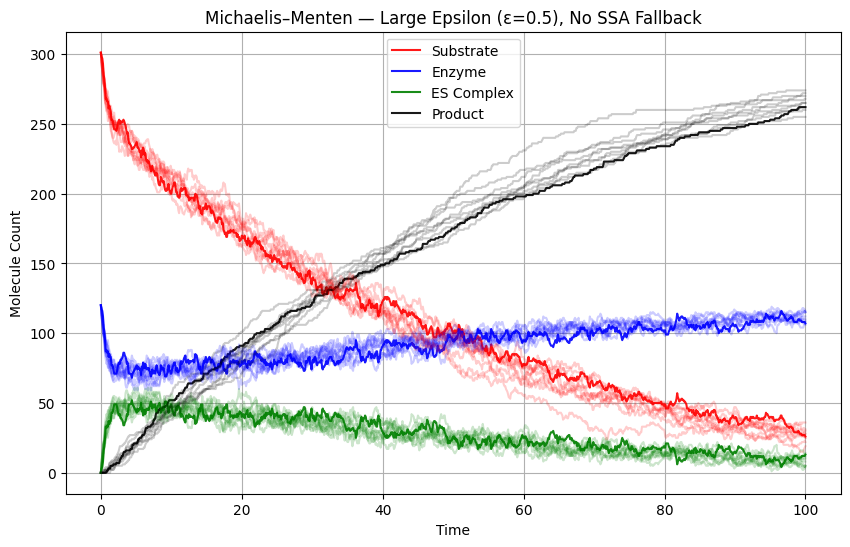

Tau steps taken: 10111
Mean tau: 0.099001
Min tau:  0.000011
Max tau:  0.100000


In [8]:
mm_model_big_eps = create_michaelis_menten()
sim_big = gillespy2.Simulation(mm_model_big_eps, "TAU", dt=0.1, end_t=100)
sim_big.solver.epsilon = 0.5
sim_big.solver.ssa_fallback = False

num_traj = 10
traj_data_big = []
for traj in range(num_traj):
    sim_big.reset()
    times = []
    substrate = []
    enzyme = []
    complex_ = []
    product = []
    prev_t = -1
    while sim_big.get_time() < sim_big.end_t:
        t = sim_big.get_time()
        if t == prev_t:
            raise RuntimeError("Time is not advancing")
        prev_t = t
        times.append(t)
        substrate.append(sim_big.get_species('Substrate'))
        enzyme.append(sim_big.get_species('Enzyme'))
        complex_.append(sim_big.get_species('Enzyme_Substrate_Complex'))
        product.append(sim_big.get_species('Product'))
        sim_big.run_until(sim_big.get_time() + sim_big.dt)
    traj_data_big.append((times, substrate, enzyme, product, complex_))

plt.figure(figsize=(10, 6))
for i, (times, substrate, enzyme, product, complex_) in enumerate(traj_data_big):
    if i == 0:
        plt.plot(times, substrate, label='Substrate', color='red', alpha=0.9)
        plt.plot(times, enzyme, label='Enzyme', color='blue', alpha=0.9)
        plt.plot(times, complex_, label='ES Complex', color='green', alpha=0.9)
        plt.plot(times, product, label='Product', color='black', alpha=0.9)
    else:
        plt.plot(times, substrate, color='red', alpha=0.2)
        plt.plot(times, enzyme, color='blue', alpha=0.2)
        plt.plot(times, complex_, color='green', alpha=0.2)
        plt.plot(times, product, color='black', alpha=0.2)

plt.xlabel('Time')
plt.ylabel('Molecule Count')
plt.title('Michaelis–Menten — Large Epsilon (ε=0.5), No SSA Fallback')
plt.legend()
plt.grid(True)
plt.show()

print(f"Tau steps taken: {len(sim_big.solver._tau_samples)}")
print(f"Mean tau: {np.mean(sim_big.solver._tau_samples):.6f}")
print(f"Min tau:  {np.min(sim_big.solver._tau_samples):.6f}")
print(f"Max tau:  {np.max(sim_big.solver._tau_samples):.6f}")

---
## Comparison: Tau Step Statistics Across Tests

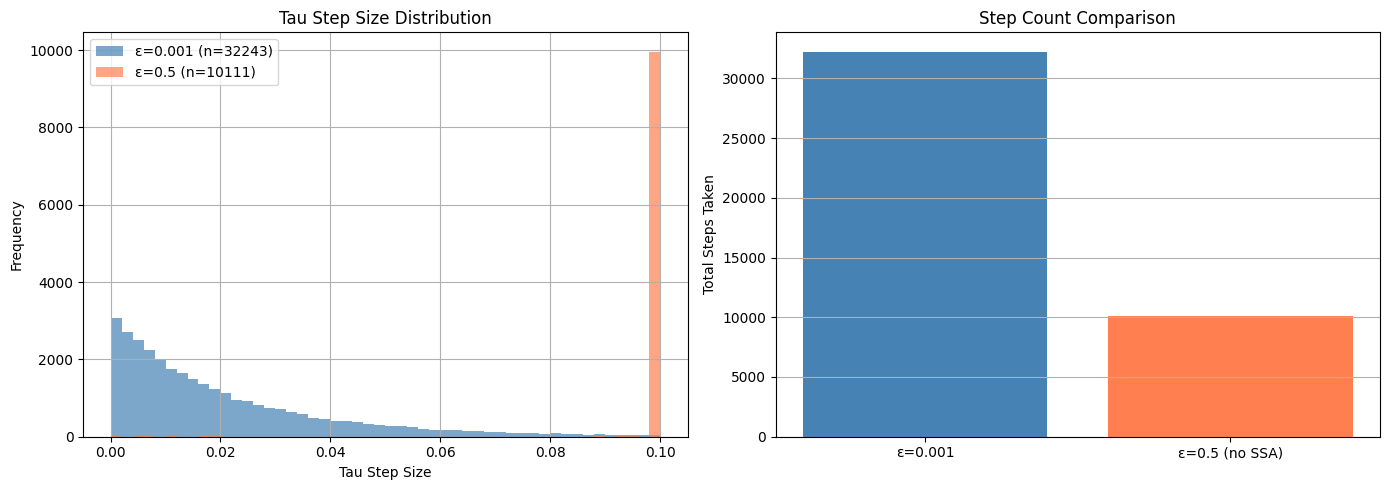

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sim_small.solver._tau_samples, bins=50, color='steelblue', alpha=0.7, label=f'ε=0.001 (n={len(sim_small.solver._tau_samples)})')
axes[0].hist(sim_big.solver._tau_samples, bins=50, color='coral', alpha=0.7, label=f'ε=0.5 (n={len(sim_big.solver._tau_samples)})')
axes[0].set_xlabel('Tau Step Size')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Tau Step Size Distribution')
axes[0].legend()
axes[0].grid(True)

labels = ['ε=0.001', 'ε=0.5 (no SSA)']
step_counts = [len(sim_small.solver._tau_samples), len(sim_big.solver._tau_samples)]
axes[1].bar(labels, step_counts, color=['steelblue', 'coral'])
axes[1].set_ylabel('Total Steps Taken')
axes[1].set_title('Step Count Comparison')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()